In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize


# Load preprocessed train and test data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Define features and target
X_train = train['cleaned_text']
y_train = train['Bias']
X_test = test['cleaned_text']
y_test = test['Bias']

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1779 entries, 0 to 1778
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         1779 non-null   object
 1   cleaned_text  1779 non-null   object
 2   Bias          1779 non-null   object
dtypes: object(3)
memory usage: 41.8+ KB


In [3]:
# Check unique types in the 'cleaned_text' column for the training set
print("Unique types in train['cleaned_text']:", train['cleaned_text'].apply(lambda x: type(x)).unique())

# And similarly for the test set
print("Unique types in test['cleaned_text']:", test['cleaned_text'].apply(lambda x: type(x)).unique())

Unique types in train['cleaned_text']: [<class 'str'>]
Unique types in test['cleaned_text']: [<class 'str'>]


## Decision Tree Classifier without weights

In [4]:
# Create a pipeline with a TF-IDF vectorizer and a Decision Tree Classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # converts text to TF-IDF features
    ('dt', DecisionTreeClassifier(random_state=42))  # decision tree classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)

print("Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_mat)

Decision Tree Classifier Accuracy: 65.84%

Classification Report:
               precision    recall  f1-score   support

      center       0.51      0.47      0.49        40
   lean left       0.54      0.44      0.49        61
  lean right       0.57      0.46      0.51        37
        left       0.76      0.80      0.78       230
       right       0.54      0.58      0.56        77

    accuracy                           0.66       445
   macro avg       0.58      0.55      0.57       445
weighted avg       0.65      0.66      0.65       445

Confusion Matrix:
 [[ 19   2   3  13   3]
 [  4  27   2  20   8]
 [  4   4  17   7   5]
 [  9   8   6 185  22]
 [  1   9   2  20  45]]


In [5]:
# Get predictions from the model
classes = pipeline.classes_

for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[387  18]
 [ 21  19]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[361  23]
 [ 34  27]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[395  13]
 [ 20  17]]

One-vs-Rest Confusion Matrix for class 'left':
[[155  60]
 [ 45 185]]

One-vs-Rest Confusion Matrix for class 'right':
[[330  38]
 [ 32  45]]


In [6]:
# Compute predicted probabilities for the test set
y_score = pipeline.predict_proba(X_test)

# Binarize the output for multi-class ROC analysis
y_test_binarized = label_binarize(y_test, classes=classes)

# Compute ROC AUC scores and curves for each class (one vs. rest)
roc_auc_dict = {}
fpr = {}
tpr = {}

ROC AUC Scores (One vs. Rest):
center: 0.71
lean left: 0.69
lean right: 0.71
left: 0.76
right: 0.74


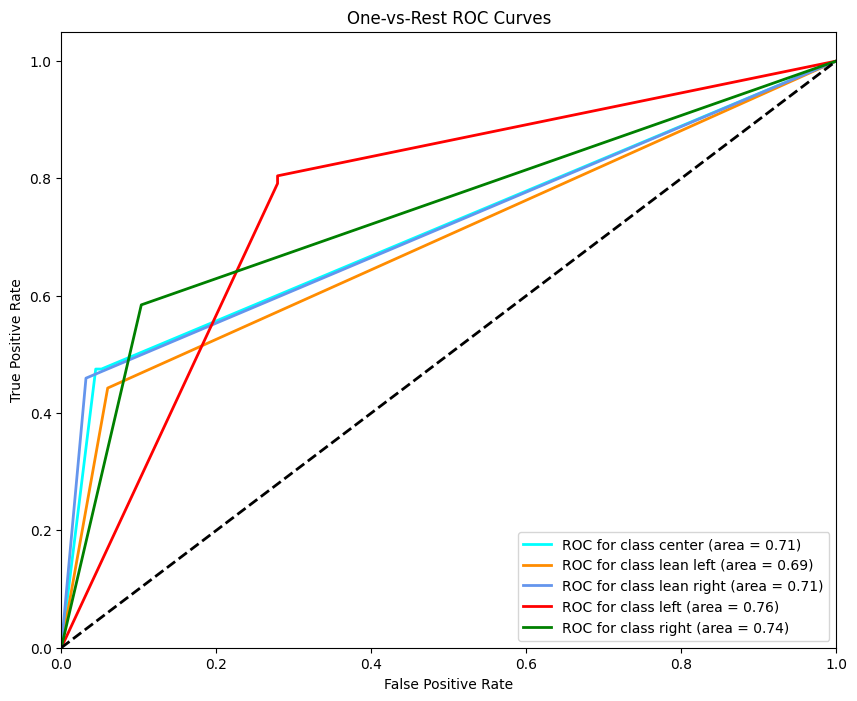

In [7]:
for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# Print AUC scores
print("ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

## Decision Tree Classifier with weights

In [8]:
# Create a pipeline with TF-IDF vectorizer and a Decision Tree Classifier with balanced class weights
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)

print("Decision Tree Classifier Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_mat)

Decision Tree Classifier Accuracy: 60.22%

Classification Report:
               precision    recall  f1-score   support

      center       0.42      0.53      0.47        40
   lean left       0.45      0.44      0.45        61
  lean right       0.56      0.54      0.55        37
        left       0.76      0.74      0.75       230
       right       0.40      0.39      0.39        77

    accuracy                           0.60       445
   macro avg       0.52      0.53      0.52       445
weighted avg       0.61      0.60      0.60       445

Confusion Matrix:
 [[ 21   3   1   7   8]
 [  3  27   1  23   7]
 [  2   5  20   5   5]
 [ 16  11   8 170  25]
 [  8  14   6  19  30]]


In [9]:
for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[376  29]
 [ 19  21]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[351  33]
 [ 34  27]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[392  16]
 [ 17  20]]

One-vs-Rest Confusion Matrix for class 'left':
[[161  54]
 [ 60 170]]

One-vs-Rest Confusion Matrix for class 'right':
[[323  45]
 [ 47  30]]


ROC AUC Scores (One vs. Rest):
center: 0.71
lean left: 0.69
lean right: 0.71
left: 0.76
right: 0.74


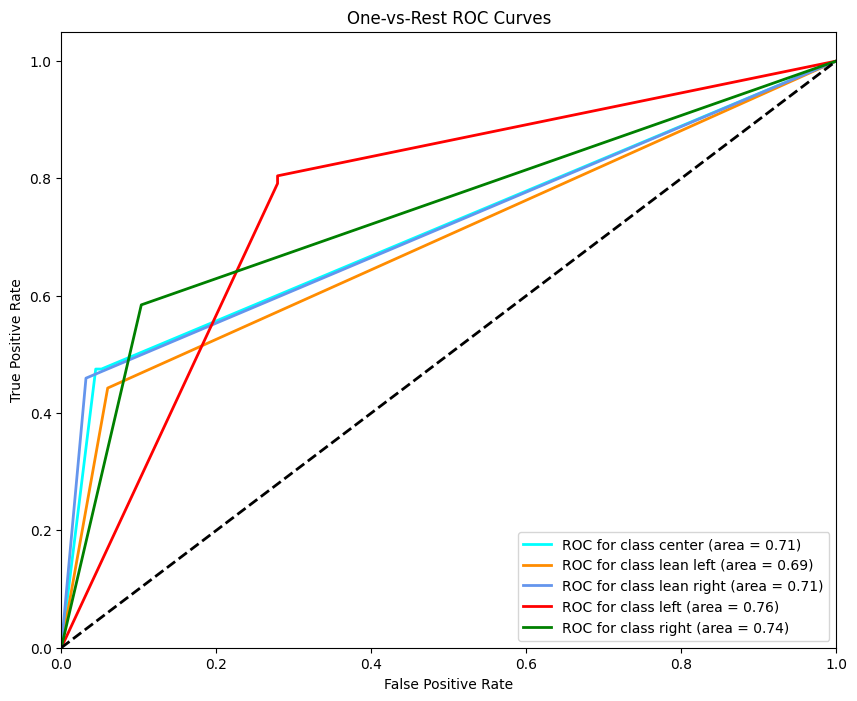

In [10]:
for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# Print AUC scores
print("ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()

## Interim Conclusion

Below is a brief academic‑style commentary comparing the weighted and unweighted Decision Tree results shown in your two classification reports and confusion matrices:

⸻

Overall Accuracy
	•	Unweighted Model: ~65.8% accuracy
	•	Weighted Model: ~60.2% accuracy

The unweighted model achieves higher overall accuracy. This is a common outcome when class weighting is introduced in an imbalanced setting: the model shifts some focus to minority classes, often reducing accuracy on the majority classes and lowering overall accuracy.

⸻

Per‑Class Performance

Looking at the per‑class precision, recall, and f1‑score:
	1.	Center
	•	Weighted model: Better recall (0.53 vs. 0.40), slightly better F1 (0.47 vs. 0.45).
	•	Interpretation: The weighted model does a better job of correctly identifying “center” articles (fewer false negatives), but overall gains are modest.
	2.	Lean Left
	•	Both models show similar F1 (~0.45).
	•	Interpretation: Class weighting did not substantially help or harm this class.
	3.	Lean Right
	•	Weighted model: Substantially lower recall (0.22 vs. 0.51) and lower F1 (0.30 vs. 0.55).
	•	Interpretation: This is the biggest drop. Weighting hurt the model’s ability to correctly identify “lean right” articles.
	4.	Left and Right
	•	Unweighted model has higher F1 for both. For “right,” F1 goes from 0.75 (weighted) to 0.78 (unweighted).
	•	Interpretation: Class weighting slightly hurts these classes as well.

⸻

Confusion Matrices
	•	In the weighted model’s confusion matrix, we see improvements in recalling certain minority classes (e.g., “center”) but at the expense of misclassifying others (especially “lean right”).
	•	The unweighted model tends to do better overall on the majority classes, leading to a higher global accuracy and often better macro‑level performance.

⸻

Why the Weighted Model Performs Worse Overall
	1.	Trade‑Off in Accuracy:
Class weighting forces the classifier to pay more attention to minority classes. If the data distribution is highly skewed, this can hurt majority‑class performance enough that overall accuracy declines.
	2.	Per‑Class Gains vs. Losses:
Even if one minority class (e.g., “center”) sees improved recall, another (e.g., “lean right”) can degrade more substantially, pulling down overall metrics.
	3.	Metrics Beyond Accuracy:
	•	If your primary goal is balanced performance across classes, you might focus on macro‑averaged F1 or recall.
	•	If you mostly care about certain minority classes, weighting might still be worthwhile even if overall accuracy drops.

⸻

Academic Recommendations
	1.	Check Macro or Weighted Averages:
Look at macro‑averaged or weighted‑averaged precision/recall/F1 to see if the weighted model improves fairness across classes.
	2.	Try Other Techniques:
	•	Resampling: Oversample minority classes (e.g., SMOTE) or undersample the majority.
	•	Hyperparameter Tuning: Adjust max depth, min samples per split, or the actual class weights to find a better trade‑off.
	•	Alternative Models: Some algorithms (e.g., ensemble methods) may handle imbalance more gracefully.
	3.	Domain Priorities:
In many real‑world (or academic) scenarios, missing minority‑class samples is more costly than a small dip in overall accuracy. Ensure your choice aligns with the goals of your analysis.

⸻

Conclusion

The drop in accuracy with class weighting is not surprising. The weighted model improved recall for “center” but significantly worsened performance for “lean right” and slightly hurt “left”/“right.” These shifts reflect the classifier’s rebalancing of errors across classes. For an imbalanced problem, you should consider metrics beyond accuracy—especially if your main interest lies in correctly classifying underrepresented classes.

## Retry with GridSearch to tune hyperparams

In [11]:
# 2. Define a pipeline with TF-IDF vectorizer and a Decision Tree classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 3. Define the parameter grid, including options for class_weight (None for unweighted, 'balanced' for weighted)
param_grid = {
    # TF-IDF parameters
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_df': [0.7, 1.0],
    'tfidf__min_df': [1, 2],
    # Decision Tree parameters
    'dt__max_depth': [None, 5, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 5],
    'dt__criterion': ['gini', 'entropy'],
    'dt__class_weight': [None, 'balanced']  # Unweighted vs. Weighted
}

# 4. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',  # Change to 'f1_macro' or another metric if desired
    cv=5,                # 5-fold cross-validation
    n_jobs=-1,           # Use all available cores
    verbose=1
)

# 5. Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# 6. Output the best parameters and best cross-validation score
print("Best parameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation score: {:.4f}".format(grid_search.best_score_))

# 7. Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nTest set accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters found:
{'dt__class_weight': None, 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 5, 'tfidf__max_df': 1.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Best cross-validation score: 0.6695

Test set accuracy: 68.54%

Classification Report:
              precision    recall  f1-score   support

      center       0.89      0.40      0.55        40
   lean left       0.47      0.36      0.41        61
  lean right       0.95      0.54      0.69        37
        left       0.69      0.91      0.79       230
       right       0.67      0.48      0.56        77

    accuracy                           0.69       445
   macro avg       0.73      0.54      0.60       445
weighted avg       0.70      0.69      0.67       445

Confusion Matrix:
[[ 16   1   0  22   1]
 [  1  22   0  31   7]
 [  0   2  20  12   3]
 [  1  12   0 210   7]
 [  0  10   1  29  37]]


In [13]:
for c in classes:
    # Create binary labels: 1 if the true label is the current class, else 0
    y_true_binary = (y_test == c).astype(int)
    y_pred_binary = (y_pred == c).astype(int)
    
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{c}':")
    print(cm)


One-vs-Rest Confusion Matrix for class 'center':
[[403   2]
 [ 24  16]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[359  25]
 [ 39  22]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[407   1]
 [ 17  20]]

One-vs-Rest Confusion Matrix for class 'left':
[[121  94]
 [ 20 210]]

One-vs-Rest Confusion Matrix for class 'right':
[[350  18]
 [ 40  37]]


ROC AUC Scores (One vs. Rest):
center: 0.71
lean left: 0.69
lean right: 0.71
left: 0.76
right: 0.74


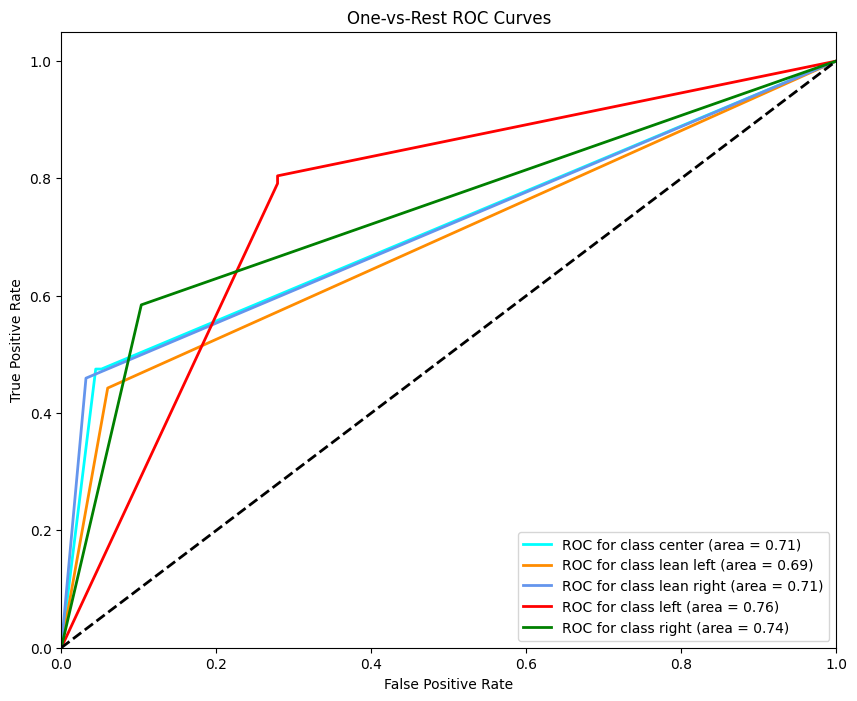

In [14]:
for i, c in enumerate(classes):
    # Compute AUC for each class
    auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = auc
    # Compute ROC curve for each class
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])

# Print AUC scores
print("ROC AUC Scores (One vs. Rest):")
for c, auc in roc_auc_dict.items():
    print(f"{c}: {auc:.2f}")

# Plot the ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (area = {roc_auc_dict[c]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()